# 作业 1 解答（可直接提交）

说明：本笔记按题目图片中的顺序完成“文档1~文档5”的理论题与编程题。

## 2 文档1：概述、线性代数和 NDArray

### 2.1 理论计算题
已知

- $\mathbf{a}=[2,-1,3]^T$
- $\mathbf{b}=[1,4,-2]^T$
- $A=\begin{bmatrix}1&0&2\\-1&3&1\end{bmatrix}$
- $B=\begin{bmatrix}2&1\\0&-1\\3&2\end{bmatrix}$

1) 向量点积：$\mathbf{a}\cdot\mathbf{b}=2\cdot1+(-1)\cdot4+3\cdot(-2)=-8$。

2) 矩阵乘法：$A\times B$ 的形状为 $(2,2)$，且
$$
A B=\begin{bmatrix}8&5\\1&-2\end{bmatrix}.
$$

3) 向量 $\mathbf{a}$ 的 Frobenius（2-范数）为
$$
\|\mathbf{a}\|_F=\sqrt{2^2+(-1)^2+3^2}=\sqrt{14}.
$$

In [1]:
import numpy as np

a = np.array([2, -1, 3])
b = np.array([1, 4, -2])
A = np.array([[1, 0, 2], [-1, 3, 1]])
B = np.array([[2, 1], [0, -1], [3, 2]])

print('a·b =', np.dot(a, b))
print('A×B =\n', A @ B)
print('shape(A×B) =', (A @ B).shape)
print('||a||_F =', np.linalg.norm(a))

a·b = -8
A×B =
 [[ 8  5]
 [ 1 -2]]
shape(A×B) = (2, 2)
||a||_F = 3.7416573867739413


### 2.2 编程题

In [2]:
np.random.seed(42)
X = np.random.randn(3, 4)
Y = np.ones((4, 2))
Z = X @ Y

print('X =\n', X)
print('Y =\n', Y)
print('Z = X @ Y =\n', Z)
print('Z第一行第二列元素 Z[0,1] =', Z[0, 1])
print('Z第二行所有元素 Z[1,:] =', Z[1, :])
print('||Z||_F =', np.linalg.norm(Z))

X =
 [[ 0.49671415 -0.1382643   0.64768854  1.52302986]
 [-0.23415337 -0.23413696  1.57921282  0.76743473]
 [-0.46947439  0.54256004 -0.46341769 -0.46572975]]
Y =
 [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]
Z = X @ Y =
 [[ 2.52916825  2.52916825]
 [ 1.87835721  1.87835721]
 [-0.85606179 -0.85606179]]
Z第一行第二列元素 Z[0,1] = 2.5291682463487657
Z第二行所有元素 Z[1,:] = [1.87835721 1.87835721]
||Z||_F = 4.616873319476864


## 3 文档2：概率与统计

### 3.1 理论计算题（贝叶斯）
患病率 $P(D)=0.001$，灵敏度 $P(+|D)=0.99$，假阳性率 $P(+|\neg D)=0.02$。

由贝叶斯公式：
$$
P(D|+) = \frac{P(+|D)P(D)}{P(+|D)P(D)+P(+|\neg D)P(\neg D)}
=\frac{0.99\times0.001}{0.99\times0.001+0.02\times0.999}
\approx 0.04721.
$$

所以检测阳性后真正患病概率约为 **4.72%**。

In [3]:
p_d = 0.001
p_pos_given_d = 0.99
p_pos_given_not_d = 0.02

p_post = (p_pos_given_d * p_d) / (p_pos_given_d * p_d + p_pos_given_not_d * (1 - p_d))
print('P(D|+) =', p_post)

P(D|+) = 0.047210300429184546


### 3.2 编程题（中心极限定理）

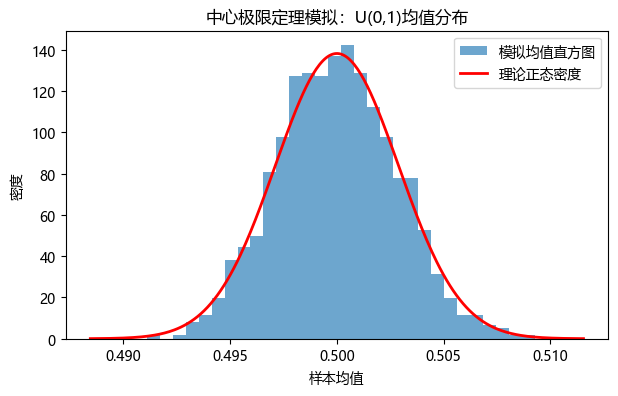

均值样本的实际方差 = 7.752783463099052e-06
理论方差 = 8.333333333333332e-06


In [9]:
import matplotlib.pyplot as plt
from matplotlib import font_manager
import matplotlib


candidate_fonts = ['Microsoft YaHei', 'SimHei', 'SimSun', 'Noto Sans CJK SC', 'Arial Unicode MS']
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
for font_name in candidate_fonts:
    if font_name in available_fonts:
        matplotlib.rcParams['font.sans-serif'] = [font_name]
        break
matplotlib.rcParams['axes.unicode_minus'] = False

np.random.seed(0)
n = 10000
m = 1000
samples = np.random.uniform(0, 1, size=(m, n))
means = samples.mean(axis=1)

mu = 0.5
sigma = np.sqrt((1 / 12) / n)

x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 300)
pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

plt.figure(figsize=(7, 4))
plt.hist(means, bins=30, density=True, alpha=0.65, label='模拟均值直方图')
plt.plot(x, pdf, 'r', lw=2, label='理论正态密度')
plt.title('中心极限定理模拟：U(0,1)均值分布')
plt.xlabel('样本均值')
plt.ylabel('密度')
plt.legend()
plt.show()

print('均值样本的实际方差 =', means.var())
print('理论方差 =', (1 / 12) / n)

## 4 文档3：导数、反向传播和复杂度

### 4.1 理论计算题
给定
$$
z=(w_1x_1+w_2x_2-y)^2,\quad x_1=2,\ x_2=1,\ y=3.
$$

记 $e=w_1x_1+w_2x_2-y$，则
$$
\frac{\partial z}{\partial w_1}=2e\cdot x_1,\quad \frac{\partial z}{\partial w_2}=2e\cdot x_2.
$$
代入常数：
$$
\frac{\partial z}{\partial w_1}=4(w_1\cdot2+w_2-3),\quad \frac{\partial z}{\partial w_2}=2(w_1\cdot2+w_2-3).
$$
当 $w_1=0.5,w_2=1$ 时，$e=2\cdot0.5+1-3=-1$，所以
$$
\frac{\partial z}{\partial w_1}=-4,\quad \frac{\partial z}{\partial w_2}=-2.
$$

In [10]:
x1, x2, y = 2, 1, 3
w1, w2 = 0.5, 1.0
e = w1 * x1 + w2 * x2 - y
dz_dw1 = 2 * e * x1
dz_dw2 = 2 * e * x2
print('dz/dw1 =', dz_dw1)
print('dz/dw2 =', dz_dw2)

dz/dw1 = -4.0
dz/dw2 = -2.0


### 4.2 编程题（手动反向传播并用 autograd 验证）

In [6]:
# 前向计算
x, w1, w2 = 2.0, 1.5, 0.5
a = x * w1
b = a + w2
L = b ** 2
print('前向结果: a=', a, ', b=', b, ', L=', L)

# 手动反向传播
dL_db = 2 * b
dL_dw2 = dL_db * 1
dL_dw1 = dL_db * 1 * x
print('手动梯度: dL/dw1=', dL_dw1, ', dL/dw2=', dL_dw2)

# 与 torch.autograd 对比
import torch
w1_t = torch.tensor(1.5, requires_grad=True)
w2_t = torch.tensor(0.5, requires_grad=True)
x_t = torch.tensor(2.0)
L_t = (x_t * w1_t + w2_t) ** 2
L_t.backward()
print('autograd梯度: dL/dw1=', float(w1_t.grad), ', dL/dw2=', float(w2_t.grad))

前向结果: a= 3.0 , b= 3.5 , L= 12.25
手动梯度: dL/dw1= 14.0 , dL/dw2= 7.0
autograd梯度: dL/dw1= 14.0 , dL/dw2= 7.0


## 5 文档4：线性方法、基础优化和 softmax 回归

### 5.1 理论计算题
模型：$\hat y_i = wx_i + b$，损失
$$
L=\frac{1}{n}\sum_{i=1}^n (y_i-\hat y_i)^2 = \frac{1}{n}\sum_{i=1}^n (y_i-(wx_i+b))^2.
$$
对参数求导得
$$
\frac{\partial L}{\partial w} = -\frac{2}{n}\sum_{i=1}^n x_i(y_i-(wx_i+b))
=\frac{2}{n}\sum_{i=1}^n (wx_i+b-y_i)x_i,
$$
$$
\frac{\partial L}{\partial b} = -\frac{2}{n}\sum_{i=1}^n (y_i-(wx_i+b))
=\frac{2}{n}\sum_{i=1}^n (wx_i+b-y_i).
$$

### 5.2 编程题（从零实现 softmax 回归，digits 数据）

In [7]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

np.random.seed(0)

digits = load_digits()
X = digits.data.astype(np.float64) / 16.0
y = digits.target.reshape(-1, 1)

enc = OneHotEncoder(sparse_output=False)
Y = enc.fit_transform(y)

X_train, X_test, Y_train, Y_test, y_train_idx, y_test_idx = train_test_split(
    X, Y, digits.target, test_size=0.2, random_state=42, stratify=digits.target
)

n_samples, n_features = X_train.shape
n_classes = Y_train.shape[1]
W = np.zeros((n_features, n_classes))
b = np.zeros((1, n_classes))

def softmax(logits):
    z = logits - np.max(logits, axis=1, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy(probs, y_onehot):
    eps = 1e-12
    return -np.mean(np.sum(y_onehot * np.log(probs + eps), axis=1))

lr = 0.1
batch_size = 32
epochs = 50

for epoch in range(epochs):
    idx = np.random.permutation(n_samples)
    X_train_shuf = X_train[idx]
    Y_train_shuf = Y_train[idx]

    for i in range(0, n_samples, batch_size):
        xb = X_train_shuf[i:i + batch_size]
        yb = Y_train_shuf[i:i + batch_size]

        logits = xb @ W + b
        probs = softmax(logits)

        grad_logits = (probs - yb) / xb.shape[0]
        grad_W = xb.T @ grad_logits
        grad_b = np.sum(grad_logits, axis=0, keepdims=True)

        W -= lr * grad_W
        b -= lr * grad_b

    if (epoch + 1) % 10 == 0:
        train_loss = cross_entropy(softmax(X_train @ W + b), Y_train)
        print(f'Epoch {epoch + 1:02d}, train loss = {train_loss:.4f}')

test_probs = softmax(X_test @ W + b)
test_pred = np.argmax(test_probs, axis=1)
test_acc = np.mean(test_pred == y_test_idx)
print('测试集准确率 =', test_acc)

Epoch 10, train loss = 0.4377
Epoch 20, train loss = 0.2918
Epoch 30, train loss = 0.2344
Epoch 40, train loss = 0.2023
Epoch 50, train loss = 0.1805
测试集准确率 = 0.9527777777777777


## 6 文档5：最大似然估计和逻辑回归

### 6.1 理论计算题
假设样本 $x_1,\dots,x_n$ 独立同分布于 $\mathcal{N}(\mu,\sigma^2)$，则似然函数
$$
L(\mu,\sigma^2)=\prod_{i=1}^n\frac{1}{\sqrt{2\pi}\sigma}\exp\left(-\frac{(x_i-\mu)^2}{2\sigma^2}\right).
$$
取对数
$$
\ell(\mu,\sigma^2)= -\frac{n}{2}\log(2\pi)-n\log\sigma-\frac{1}{2\sigma^2}\sum_{i=1}^n(x_i-\mu)^2.
$$
对 $\mu$ 求导并令其为 0，可得
$$
\hat\mu = \frac{1}{n}\sum_{i=1}^n x_i.
$$
再对 $\sigma^2$ 求导并令其为 0，可得
$$
\hat\sigma^2 = \frac{1}{n}\sum_{i=1}^n (x_i-\hat\mu)^2.
$$

### 6.2 编程题（从零实现二分类逻辑回归）

Iter 0200, loss = 0.0208
Iter 0400, loss = 0.0139
Iter 0600, loss = 0.0111
Iter 0800, loss = 0.0095
Iter 1000, loss = 0.0085
新生成测试集准确率 = 0.99


c:\Users\y2453\.conda\envs\data_analysis\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36923 (\N{CJK UNIFIED IDEOGRAPH-903B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\y2453\.conda\envs\data_analysis\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36753 (\N{CJK UNIFIED IDEOGRAPH-8F91}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\y2453\.conda\envs\data_analysis\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22238 (\N{CJK UNIFIED IDEOGRAPH-56DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\y2453\.conda\envs\data_analysis\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24402 (\N{CJK UNIFIED IDEOGRAPH-5F52}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\y2453\.conda\envs\data_analysis\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarni

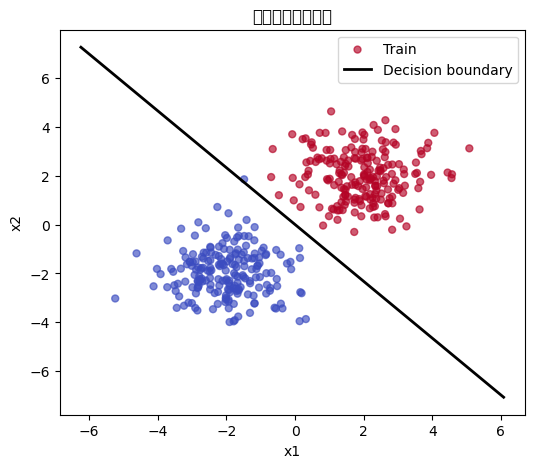

In [ ]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from matplotlib import font_manager
import matplotlib

# 自动选择本机可用中文字体，避免中文乱码
candidate_fonts = ['Microsoft YaHei', 'SimHei', 'SimSun', 'Noto Sans CJK SC', 'Arial Unicode MS']
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
for font_name in candidate_fonts:
    if font_name in available_fonts:
        matplotlib.rcParams['font.sans-serif'] = [font_name]
        break
matplotlib.rcParams['axes.unicode_minus'] = False

np.random.seed(42)

# 生成两类可分数据：每类200个，2维
X_train, y_train = make_blobs(n_samples=400, centers=[(-2, -2), (2, 2)], cluster_std=1.0, random_state=42)

# 额外测试集：100个样本
X_test_new, y_test_new = make_blobs(n_samples=100, centers=[(-2, -2), (2, 2)], cluster_std=1.0, random_state=123)

w = np.zeros((2, 1))
b = 0.0

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def bce_loss(y_true, y_prob):
    eps = 1e-12
    y_prob = np.clip(y_prob, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))

lr = 0.1
iters = 1000
N = X_train.shape[0]
y_train_col = y_train.reshape(-1, 1)

for t in range(iters):
    logits = X_train @ w + b
    y_prob = sigmoid(logits)

    grad_w = (X_train.T @ (y_prob - y_train_col)) / N
    grad_b = np.mean(y_prob - y_train_col)

    w -= lr * grad_w
    b -= lr * grad_b

    if (t + 1) % 200 == 0:
        loss = bce_loss(y_train_col, y_prob)
        print(f'Iter {t + 1:04d}, loss = {loss:.4f}')

# 测试准确率
test_prob = sigmoid(X_test_new @ w + b)
test_pred = (test_prob >= 0.5).astype(int).ravel()
acc = np.mean(test_pred == y_test_new)
print('新生成测试集准确率 =', acc)

# 绘制决策边界
plt.figure(figsize=(6, 5))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', alpha=0.65, s=25, label='Train')

x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
xx = np.linspace(x_min, x_max, 200)
if abs(w[1, 0]) > 1e-12:
    yy = -(w[0, 0] * xx + b) / w[1, 0]
    plt.plot(xx, yy, 'k-', lw=2, label='Decision boundary')

plt.title('逻辑回归决策边界')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.show()